In [5]:
import numpy as np
import sep

In [6]:
# additional setup for reading the test image and displaying plots
from astropy.io import fits
import matplotlib.pyplot as plt
from matplotlib import rcParams

%matplotlib inline

rcParams['figure.figsize'] = [10., 8.]

In [7]:
hdul = fits.open("jw02731-o001_t017_nircam_clear-f090w_i2d.fits")

image_data = hdul[1].data.astype(np.float32)

image_data = np.nan_to_num(image_data, nan=0.0)
hdul.close()

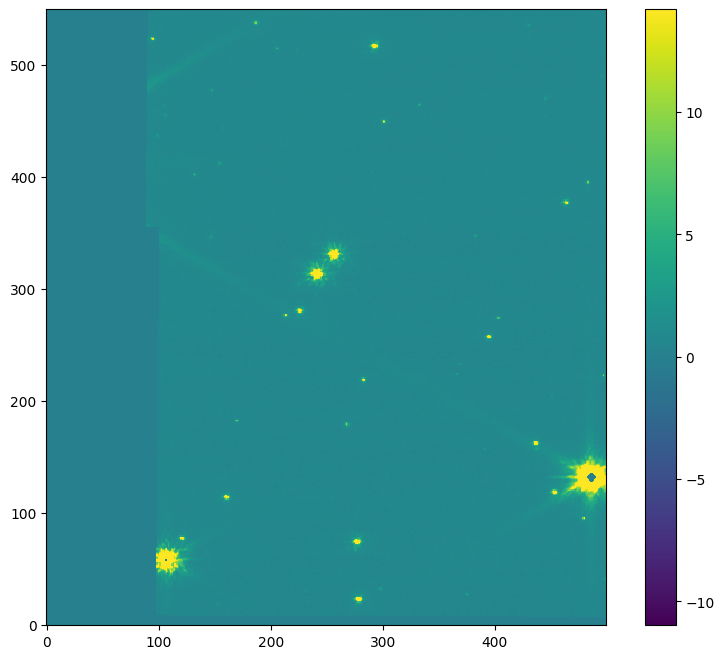

In [8]:
# show the image
m, s = np.mean(image_data), np.std(image_data)
plt.imshow(image_data[:550, :500], interpolation='nearest', vmin=m-s, vmax=m+s, origin='lower')
plt.colorbar();
plt.show();

In [9]:
new_data = image_data.astype(image_data.dtype.newbyteorder("="))
new_data = image_data.byteswap()
new_data = new_data.view(new_data.dtype.newbyteorder("="))
data = image_data.byteswap()
data = image_data.view(data.dtype.newbyteorder("="))

In [10]:
# measure a spatially varying background on the image
bkg = sep.Background(data)

In [11]:
mask = data == 0

bkg = sep.Background(data, mask=mask, bw=64, bh=64, fw=3, fh=3)

In [12]:
# get a "global" mean and noise of the image background:
print(bkg.globalback)
print(bkg.globalrms)

1.1997147798538208
0.06582547724246979


In [13]:
# evaluate background as 2-d array, same size as original image
bkg_image = bkg.back()
# bkg_image = np.array(bkg) #equivalent to above

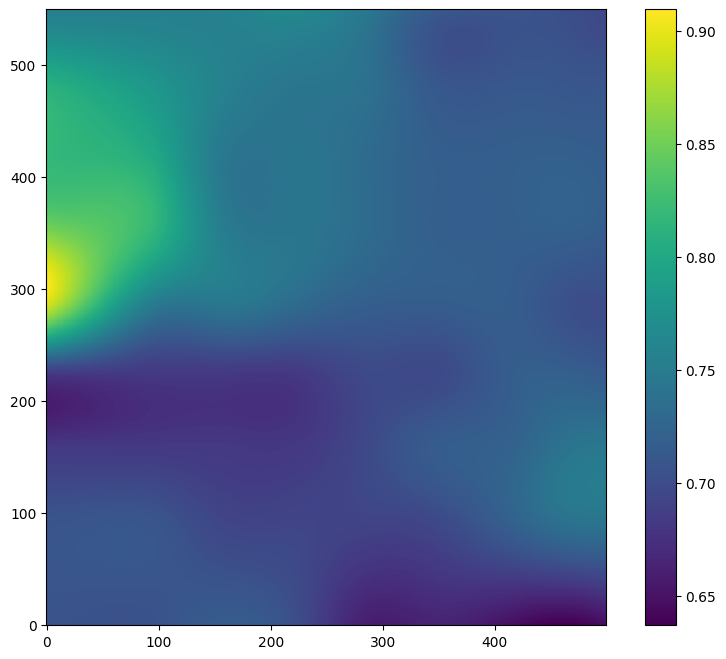

In [14]:
# show the background
plt.imshow(bkg_image[:550, :500], interpolation = 'nearest', origin = 'lower')
plt.colorbar();
plt.show();

In [15]:
# evaluate the background noise as 2-d array, same size as original image
bkg_rms = bkg.rms()

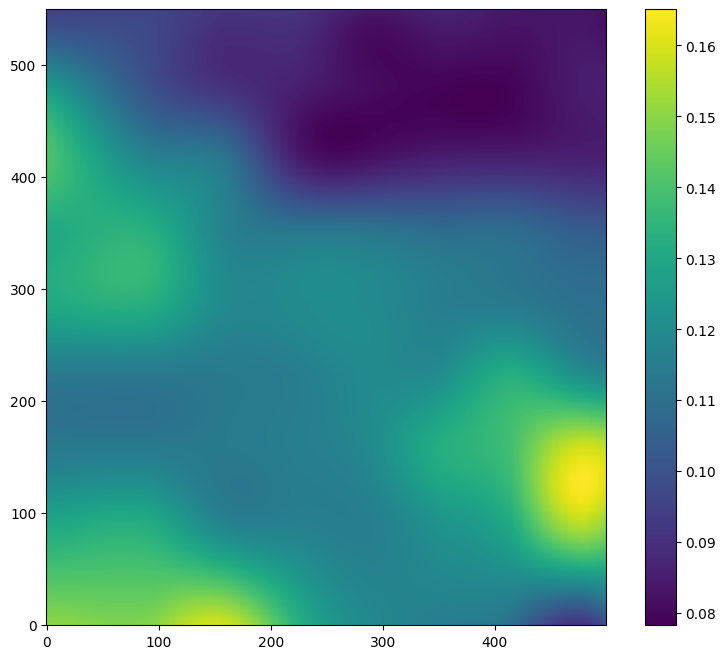

In [16]:
# show the background noise
plt.imshow(bkg_rms[:550, :500], interpolation = 'nearest', origin = 'lower')
plt.colorbar();
plt.savefig('noise.png', bbox_inches = 'tight', dpi = 300)

In [17]:
# Get background model
bkg_data = bkg.back()

# Clean data and background of NaNs and Infs
data = np.nan_to_num(data, nan=0.0, posinf=0.0, neginf=0.0)
bkg_data = np.nan_to_num(bkg_data, nan=0.0, posinf=0.0, neginf=0.0)

# subtract the background
data_sub = data - bkg_data

In [18]:
objects = sep.extract(data_sub[:500, :500].copy(), 1.5, err=bkg.globalrms)

In [19]:
# how many objects were detected
len(objects)

313

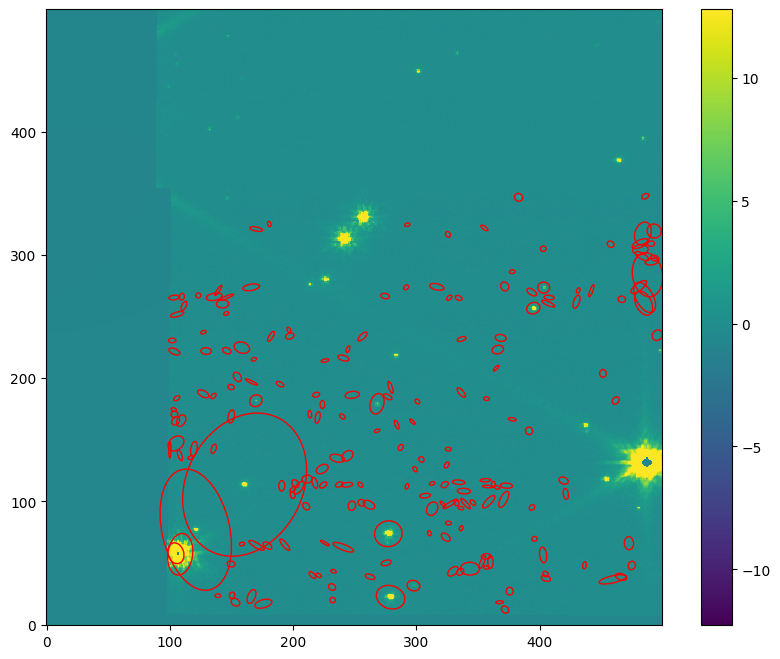

In [20]:
# Plot:
from matplotlib.patches import Ellipse

fig, ax = plt.subplots()
m, s = np.mean(data_sub), np.std(data_sub)
im = ax.imshow(data_sub[:500, :500], interpolation = 'nearest', 
               vmin = m-s, vmax = m+s, origin = 'lower')

visible = (objects['x'] < 500) & (objects['y'] < 500)
indices = np.where(visible)[0][:200]

for i in indices:
    e = Ellipse(xy = (objects['x'][i], objects['y'][i]),
                width=6*objects['a'][i],
                height=6*objects['b'][i],
                angle=objects['theta'][i] * 180./np.pi)
    e.set_facecolor('none')
    e.set_edgecolor('red')
    ax.add_artist(e)
    
plt.colorbar(im, ax=ax)
plt.savefig('obj_dect.png', bbox_inches = 'tight', dpi = 300)
plt.show();
plt.close()

In [21]:
# available fields
objects.dtype.names

('thresh',
 'npix',
 'tnpix',
 'xmin',
 'xmax',
 'ymin',
 'ymax',
 'x',
 'y',
 'x2',
 'y2',
 'xy',
 'errx2',
 'erry2',
 'errxy',
 'a',
 'b',
 'theta',
 'cxx',
 'cyy',
 'cxy',
 'cflux',
 'flux',
 'cpeak',
 'peak',
 'xcpeak',
 'ycpeak',
 'xpeak',
 'ypeak',
 'flag')

In [22]:
flux, fluxerr, flag = sep.sum_circle(data_sub, objects['x'], objects['y'],
                                     3.0, err = bkg.globalrms, gain = 1.0)

In [23]:
# show the first 10 objects results:
for i in range(10):
    print("object {:d}: flux = {:f} +/- {:f}".format(i, flux[i], fluxerr[i]))

object 0: flux = 3.611611 +/- 1.932305
object 1: flux = 0.731489 +/- 0.924135
object 2: flux = 9.183903 +/- 3.050532
object 3: flux = 3.034399 +/- 1.776728
object 4: flux = 1.833663 +/- 1.398704
object 5: flux = 1.005662 +/- 1.062330
object 6: flux = 2.017765 +/- 1.462977
object 7: flux = 2.974730 +/- 1.759807
object 8: flux = 15.189217 +/- 3.912979
object 9: flux = 5.571911 +/- 2.386232


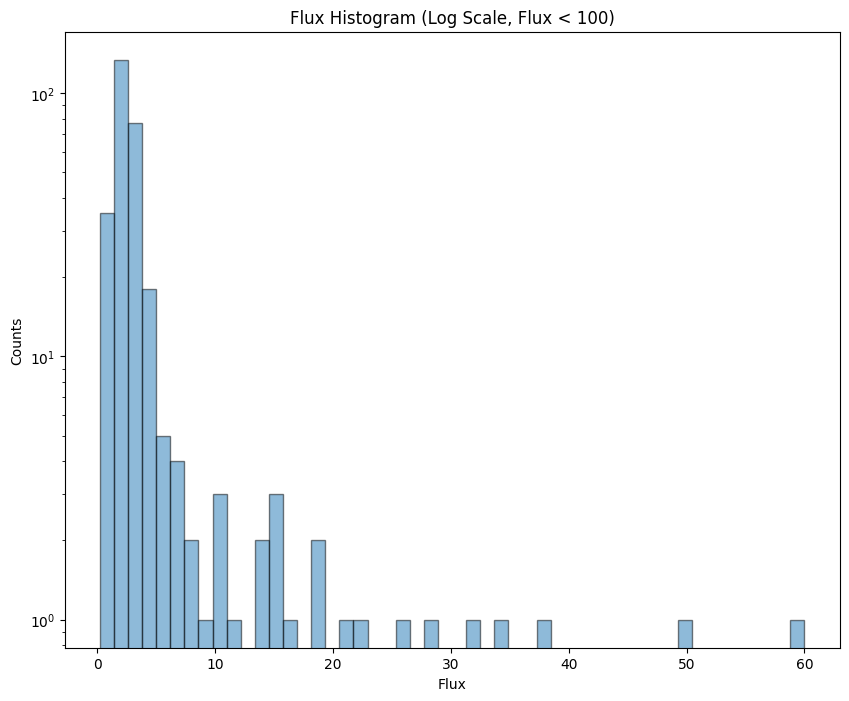

In [24]:
# create the flux histogram
# had to clip the flux because there were a lot of outliers that skewed the distribution

width = 0.1
good = np.isfinite(flux) & (flux > 0) & (flag == 0)
good_flux = flux[good]
hist_min = np.floor(np.min(good_flux))
hist_max = np.ceil(np.max(good_flux)) + width

bins = np.arange(hist_min, hist_max, width) #this array contains the borders of the bins 

#create the histogram
clipped_flux = good_flux[good_flux < 100]

plt.hist(clipped_flux, bins=50, alpha=0.5, edgecolor='black')
plt.xlabel('Flux')
plt.ylabel('Counts')
plt.yscale('log')
plt.title('Flux Histogram (Log Scale, Flux < 100)')
plt.show()

In [25]:
mean_flux = np.mean(good_flux)
print(mean_flux)

91.33695428272472


In [26]:
median_flux = np.median(good_flux)
print(median_flux)

2.5349693083763127


In [27]:
std_flux = np.std(good_flux)
print(std_flux)

621.1172155295263


In [28]:
largest_flux = np.max(good_flux)
print(largest_flux)

6138.620173454286


In [29]:
good_idx = np.argmax(good_flux)
good_ind = np.where(good)[0]
obj_idx = good_ind[good_idx]

x_val = objects['x'][obj_idx]
y_val = objects['y'][obj_idx]

print(x_val, y_val)

241.44879123933708 313.445480411308


In [30]:
print((largest_flux - mean_flux)/std_flux)

9.73613847430717


In [31]:
# ---------------------------------
# 0. Copy all this script into one cell, between steps 7 and 8 of your final project
#    You will need to install the "reproject" package with pip`
#    This script will "reproject" all images onto the same shape using one image as a reference
# ---------------------------------

from astropy.io import fits
from astropy.wcs import WCS
from reproject import reproject_interp

# ---------------------------------
# 1. Load your reference image
#    This will define the WCS and shape for all others
# ---------------------------------
file_reference = "jw02731-o001_t017_nircam_clear-f090w_i2d.fits"
with fits.open(file_reference) as hdulist:
    # For JWST i2d images, 'SCI' is commonly the science extension
    ref_header = hdulist['SCI'].header
    ref_data = hdulist['SCI'].data

# Create a WCS object from the reference
ref_wcs = WCS(ref_header)

# This shape will be used for all reprojected images
output_shape = ref_data.shape

# ---------------------------------
# 2. Reproject the other images
# ---------------------------------
fname1 = "jw02731-o001_t017_nircam_clear-f187n_i2d.fits"
fname2 = "jw02731-o001_t017_nircam_clear-f200w_i2d.fits"
fname3 = "jw02731-o001_t017_nircam_clear-f335m_i2d.fits"
fname4 = "jw02731-o001_t017_nircam_clear-f444w_i2d.fits"
fname5 = "jw02731-o001_t017_nircam_f444w-f470n_i2d.fits"

other_filenames = [
    fname1,
    fname2,
    fname3,
    fname4,
    fname5,
]

# Reproject all other files according to the reference
for fname in other_filenames:
    with fits.open(fname) as hdulist:
        data = hdulist['SCI'].data
        header = hdulist['SCI'].header
        wcs_in = WCS(header)
    
    # Reproject this image onto the reference WCS
    # reproject_interp returns (reprojected_data, footprint)
    reprojected_data, footprint = reproject_interp(
        (data, wcs_in),
        ref_wcs,
        shape_out=output_shape
    )

    # Optionally, update the header to match the reference WCS
    # so that the new FITS is self-consistent
    new_header = ref_header.copy()

    # Save the new file
    out_name = fname.replace('.fits', '_reproj.fits')
    hdu = fits.PrimaryHDU(reprojected_data, header=new_header)
    hdu.writeto(out_name, overwrite=True)
    print(f"Reprojected {fname} -> {out_name}")

Set DATE-AVG to '2022-06-03T12:17:28.687' from MJD-AVG.
Set DATE-END to '2022-06-03T14:54:43.830' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -31.567170 from OBSGEO-[XYZ].
Set OBSGEO-H to 1654335564.228 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set DATE-AVG to '2022-06-03T11:43:37.007' from MJD-AVG.
Set DATE-END to '2022-06-03T14:26:16.631' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -31.557313 from OBSGEO-[XYZ].
Set OBSGEO-H to 1654186065.609 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


Reprojected jw02731-o001_t017_nircam_clear-f187n_i2d.fits -> jw02731-o001_t017_nircam_clear-f187n_i2d_reproj.fits


Set DATE-AVG to '2022-06-03T12:45:26.326' from MJD-AVG.
Set DATE-END to '2022-06-03T15:22:38.772' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -31.574431 from OBSGEO-[XYZ].
Set OBSGEO-H to 1654445751.087 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


Reprojected jw02731-o001_t017_nircam_clear-f200w_i2d.fits -> jw02731-o001_t017_nircam_clear-f200w_i2d_reproj.fits


Set DATE-AVG to '2022-06-03T12:17:28.706' from MJD-AVG.
Set DATE-END to '2022-06-03T14:54:43.830' from MJD-END'. [astropy.wcs.wcs]


Reprojected jw02731-o001_t017_nircam_clear-f335m_i2d.fits -> jw02731-o001_t017_nircam_clear-f335m_i2d_reproj.fits


Set DATE-AVG to '2022-06-03T12:45:26.346' from MJD-AVG.
Set DATE-END to '2022-06-03T15:22:38.772' from MJD-END'. [astropy.wcs.wcs]


Reprojected jw02731-o001_t017_nircam_clear-f444w_i2d.fits -> jw02731-o001_t017_nircam_clear-f444w_i2d_reproj.fits


Set DATE-AVG to '2022-06-03T11:43:37.025' from MJD-AVG.
Set DATE-END to '2022-06-03T14:26:16.695' from MJD-END'. [astropy.wcs.wcs]


Reprojected jw02731-o001_t017_nircam_f444w-f470n_i2d.fits -> jw02731-o001_t017_nircam_f444w-f470n_i2d_reproj.fits


In [32]:
filters = [
    "jw02731-o001_t017_nircam_clear-f090w_i2d.fits",  #reference
    "jw02731-o001_t017_nircam_clear-f187n_i2d_reproj.fits",
    "jw02731-o001_t017_nircam_clear-f200w_i2d_reproj.fits",
    "jw02731-o001_t017_nircam_clear-f335m_i2d_reproj.fits",
    "jw02731-o001_t017_nircam_clear-f444w_i2d_reproj.fits",
    "jw02731-o001_t017_nircam_f444w-f470n_i2d_reproj.fits"
]

def normalize(data):
    vmin, vmax = np.percentile(data, [1, 99])
    return np.clip((data - vmin) / (vmax - vmin), 0, 1)

data_stack = []
for f in filters:
    img = fits.getdata(f)
    img = np.nan_to_num(img, nan=0.0)
    data_stack.append(normalize(img))

In [33]:
#Add filters & normalize
red = normalize(data_stack[0] + data_stack[1])  # F444W + F470N
green = normalize(data_stack[2] + data_stack[3])  # F200W + F335M 
blue = normalize(data_stack[4] + data_stack[5])  # F090W + F187N 

# Make into RGB
rgb = np.dstack([red, green, blue])

In [34]:
# Saving the image

plt.figure(figsize=(10, 10))
plt.imshow(rgb, origin='lower')
plt.axis('off')
plt.savefig("ngc3324_3color_combined.png", dpi=300, bbox_inches='tight')
plt.close()